# Financial Health Prediction – Zindi Challenge

**Métrique :** F1-score weighted  
**Approche :** LightGBM + XGBoost + CatBoost → ensemble par blending  
**Attention :** classes très déséquilibrées (Low 65%, Medium 30%, High 5%)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from itertools import product as iproduct

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)

## 1. Chargement

In [2]:
train = pd.read_csv('/kaggle/input/datasets/miradoandrianiaina/financial-health-prediction-dataset/Train.csv')
test  = pd.read_csv('/kaggle/input/datasets/miradoandrianiaina/financial-health-prediction-dataset/Test.csv')
ID_COL  = 'ID'
TGT_COL = 'Target'

print(f'train={train.shape}  test={test.shape}')
print(train[TGT_COL].value_counts())

train=(9618, 39)  test=(2405, 38)
Target
Low       6280
Medium    2868
High       470
Name: count, dtype: int64


## 2. EDA rapide

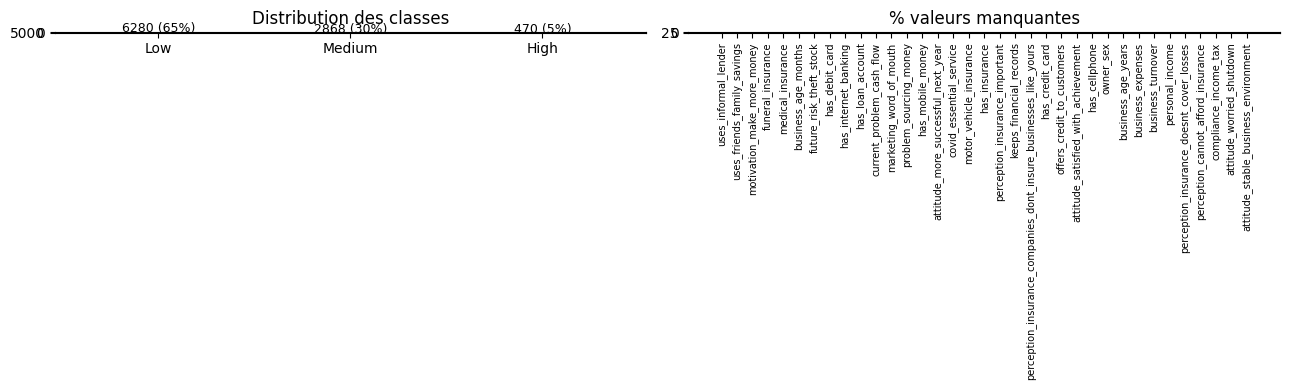

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# distribution des classes
counts = train[TGT_COL].value_counts().reindex(['Low','Medium','High'])
axes[0].bar(counts.index, counts.values, color=['#e74c3c','#f39c12','#27ae60'])
axes[0].set_title('Distribution des classes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+30, f'{v} ({v/len(train)*100:.0f}%)', ha='center', fontsize=9)

# % valeurs manquantes
miss = (train.isnull().mean()*100).sort_values(ascending=False)
miss = miss[miss > 0]
axes[1].bar(range(len(miss)), miss.values,
            color=['#e74c3c' if x>40 else '#f39c12' if x>20 else '#3498db' for x in miss.values])
axes[1].set_title('% valeurs manquantes')
axes[1].set_xticks(range(len(miss)))
axes[1].set_xticklabels(miss.index, rotation=90, fontsize=7)

plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [4]:
train['_split'] = 'train'
test['_split']  = 'test'
test[TGT_COL]   = np.nan
df = pd.concat([train, test], ignore_index=True)

# --- indicateurs de manquants pour colonnes très incomplètes ---
for col in df.columns:
    if col in [ID_COL, TGT_COL, '_split']: continue
    if df[col].isnull().mean() > 0.3:
        df[f'{col}_na'] = df[col].isnull().astype(int)

# --- nombre total de champs manquants par ligne ---
feats_tmp = [c for c in df.columns if c not in [ID_COL, TGT_COL, '_split']]
df['n_missing'] = df[feats_tmp].isnull().sum(axis=1)

# --- score d'accès aux services financiers ---
fin_cols = ['has_mobile_money','has_credit_card','has_loan_account',
            'has_internet_banking','has_debit_card','has_insurance']
fin_cols = [c for c in fin_cols if c in df.columns]
yes_no = lambda x: 1 if str(x).lower() in ['yes','1'] else (0 if str(x).lower() in ['no','0'] else np.nan)
df['fin_access_score'] = df[fin_cols].applymap(yes_no).sum(axis=1)

# --- score d'assurance ---
ins_cols = [c for c in ['motor_vehicle_insurance','medical_insurance','funeral_insurance','has_insurance'] if c in df.columns]
df['insurance_score'] = df[ins_cols].applymap(yes_no).sum(axis=1)

# --- ratios financiers ---
df['profit_proxy']   = df['business_turnover'] - df['business_expenses']
df['expense_ratio']  = df['business_expenses'] / df['business_turnover'].replace(0, np.nan)
df['biz_age_months_total'] = df['business_age_years'].fillna(0)*12 + df['business_age_months'].fillna(0)

# --- fréquence par pays ---
freq = df[df['_split']=='train']['country'].value_counts(normalize=True)
df['country_freq'] = df['country'].map(freq)

print(f'Colonnes après FE : {df.shape[1]}')

Colonnes après FE : 60


## 4. Encodage & Préparation

In [5]:
# encodage label des colonnes catégorielles
cat_cols = [c for c in df.columns if df[c].dtype=='object' and c not in [ID_COL, TGT_COL, '_split']]
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str).fillna('NA'))

# encodage de la target
le_tgt = LabelEncoder()
le_tgt.fit(df[df['_split']=='train'][TGT_COL].dropna())
print('Classes :', le_tgt.classes_)

# split train/test
FEATS = [c for c in df.columns if c not in [ID_COL, TGT_COL, '_split']]

train_df = df[df['_split']=='train'].reset_index(drop=True)
test_df  = df[df['_split']=='test'].reset_index(drop=True)

X      = train_df[FEATS]
y      = le_tgt.transform(train_df[TGT_COL]).astype(int)
X_test = test_df[FEATS]

# imputation médiane
imp    = SimpleImputer(strategy='median')
X      = pd.DataFrame(imp.fit_transform(X),     columns=FEATS)
X_test = pd.DataFrame(imp.transform(X_test),    columns=FEATS)

# poids de classes pour XGBoost
cw = compute_class_weight('balanced', classes=np.unique(y), y=y)
cw_dict = dict(enumerate(cw))
sw = np.array([cw_dict[i] for i in y])

N_CLASSES = len(le_tgt.classes_)
print(f'Features={len(FEATS)}  |  class weights={cw_dict}')

Classes : ['High' 'Low' 'Medium']
Features=57  |  class weights={0: np.float64(6.821276595744681), 1: np.float64(0.5105095541401274), 2: np.float64(1.1178521617852162)}


## 5. Entraînement (CV 5-folds)

In [6]:
N_FOLDS = 5
skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof   = {}   # out-of-fold predictions
ptest = {}   # test predictions

def run_cv(name, model_fn):
    """Boucle CV générique — retourne OOF et prédictions test."""
    oof_arr  = np.zeros((len(X), N_CLASSES))
    test_arr = np.zeros((len(X_test), N_CLASSES))
    scores   = []

    print(f'\n--- {name} ---')
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
        ytr, yval = y[tr_idx], y[val_idx]

        m = model_fn(Xtr, ytr, Xval, yval, tr_idx)
        oof_arr[val_idx] = m.predict_proba(Xval)
        test_arr        += m.predict_proba(X_test) / N_FOLDS

        s = f1_score(yval, np.argmax(m.predict_proba(Xval), axis=1), average='weighted')
        scores.append(s)
        print(f'  fold {fold+1}  f1={s:.4f}')

    oof_f1 = f1_score(y, np.argmax(oof_arr, axis=1), average='weighted')
    print(f'  → OOF F1={oof_f1:.4f}  mean={np.mean(scores):.4f}')
    return oof_arr, test_arr

In [7]:
# ---------- LightGBM ----------
def fit_lgbm(Xtr, ytr, Xval, yval, _):
    m = lgb.LGBMClassifier(
        objective='multiclass', num_class=N_CLASSES,
        n_estimators=2000, learning_rate=0.03,
        num_leaves=63, min_child_samples=20,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        reg_alpha=0.05, reg_lambda=0.1,
        class_weight='balanced', random_state=SEED,
        verbose=-1, n_jobs=-1
    )
    m.fit(Xtr, ytr, eval_set=[(Xval, yval)],
          callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
    return m

oof['lgbm'], ptest['lgbm'] = run_cv('LightGBM', fit_lgbm)


--- LightGBM ---
  fold 1  f1=0.8480
  fold 2  f1=0.8744
  fold 3  f1=0.8638
  fold 4  f1=0.8602
  fold 5  f1=0.8761
  → OOF F1=0.8645  mean=0.8645


In [8]:
# ---------- XGBoost ----------
def fit_xgb(Xtr, ytr, Xval, yval, tr_idx):
    m = xgb.XGBClassifier(
        objective='multi:softprob', num_class=N_CLASSES,
        n_estimators=2000, learning_rate=0.03,
        max_depth=6, min_child_weight=5,
        subsample=0.8, colsample_bytree=0.8,
        gamma=0.1, reg_alpha=0.05, reg_lambda=1.0,
        early_stopping_rounds=100,   # ici dans les params (XGBoost >= 2.0)
        eval_metric='mlogloss',
        tree_method='hist', random_state=SEED, n_jobs=-1, verbosity=0
    )
    m.fit(Xtr, ytr, sample_weight=sw[tr_idx],
          eval_set=[(Xval, yval)], verbose=False)
    return m

oof['xgb'], ptest['xgb'] = run_cv('XGBoost', fit_xgb)


--- XGBoost ---
  fold 1  f1=0.8469
  fold 2  f1=0.8663
  fold 3  f1=0.8519
  fold 4  f1=0.8526
  fold 5  f1=0.8722
  → OOF F1=0.8580  mean=0.8580


In [9]:
# ---------- CatBoost ----------
# subsample nécessite bootstrap_type='Bernoulli' (défaut=Bayesian ne le supporte pas)
def fit_cat(Xtr, ytr, Xval, yval, _):
    m = CatBoostClassifier(
        loss_function='MultiClass', eval_metric='TotalF1',
        iterations=2000, learning_rate=0.03,
        depth=6, l2_leaf_reg=3,
        bootstrap_type='Bernoulli', subsample=0.8,  # Bernoulli requis pour subsample
        auto_class_weights='Balanced',
        random_seed=SEED, verbose=0
    )
    m.fit(Xtr, ytr, eval_set=(Xval, yval),
          early_stopping_rounds=100, verbose=False)
    return m

oof['cat'], ptest['cat'] = run_cv('CatBoost', fit_cat)


--- CatBoost ---
  fold 1  f1=0.8327
  fold 2  f1=0.8371
  fold 3  f1=0.8184
  fold 4  f1=0.8227
  fold 5  f1=0.8505
  → OOF F1=0.8322  mean=0.8323


## 6. Ensemble (recherche des poids optimaux)

In [10]:
best_f1, best_w = 0, (1/3, 1/3, 1/3)

for w1, w2 in iproduct(np.arange(0.05, 0.91, 0.05), np.arange(0.05, 0.91, 0.05)):
    w3 = round(1 - w1 - w2, 4)
    if not (0.05 <= w3 <= 0.90): continue
    blend = w1*oof['lgbm'] + w2*oof['xgb'] + w3*oof['cat']
    f1 = f1_score(y, np.argmax(blend, axis=1), average='weighted')
    if f1 > best_f1:
        best_f1, best_w = f1, (w1, w2, w3)

w1, w2, w3 = best_w
print(f'Poids optimaux → LGBM={w1:.2f}  XGB={w2:.2f}  CAT={w3:.2f}')
print(f'F1 OOF Ensemble : {best_f1:.4f}')

Poids optimaux → LGBM=0.85  XGB=0.10  CAT=0.05
F1 OOF Ensemble : 0.8646


In [11]:
oof_blend  = w1*oof['lgbm']   + w2*oof['xgb']   + w3*oof['cat']
test_blend = w1*ptest['lgbm'] + w2*ptest['xgb'] + w3*ptest['cat']

y_oof_pred  = np.argmax(oof_blend,  axis=1)
y_test_pred = np.argmax(test_blend, axis=1)

print(f'F1 final OOF : {f1_score(y, y_oof_pred, average="weighted"):.4f}')
print(classification_report(y, y_oof_pred, target_names=le_tgt.classes_))

F1 final OOF : 0.8646
              precision    recall  f1-score   support

        High       0.76      0.68      0.72       470
         Low       0.91      0.92      0.92      6280
      Medium       0.78      0.77      0.78      2868

    accuracy                           0.87      9618
   macro avg       0.82      0.79      0.80      9618
weighted avg       0.86      0.87      0.86      9618



## 7. Résultats

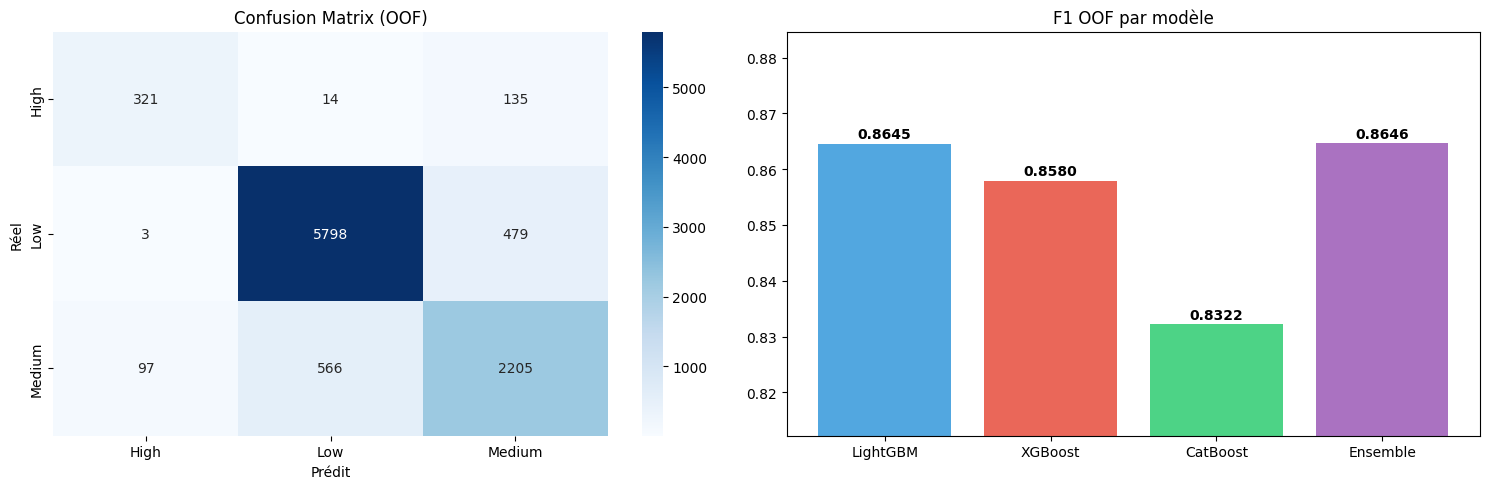

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# matrice de confusion
cm = confusion_matrix(y, y_oof_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_tgt.classes_, yticklabels=le_tgt.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (OOF)')
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')

# comparaison modèles
names = ['LightGBM', 'XGBoost', 'CatBoost', 'Ensemble']
f1s   = [f1_score(y, np.argmax(oof[k], axis=1), average='weighted') for k in ['lgbm','xgb','cat']]
f1s  += [f1_score(y, y_oof_pred, average='weighted')]
bars  = axes[1].bar(names, f1s, color=['#3498db','#e74c3c','#2ecc71','#9b59b6'], alpha=0.85)
for b, v in zip(bars, f1s):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.001, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_ylim(min(f1s)-0.02, max(f1s)+0.02)
axes[1].set_title('F1 OOF par modèle')

plt.tight_layout()
plt.show()

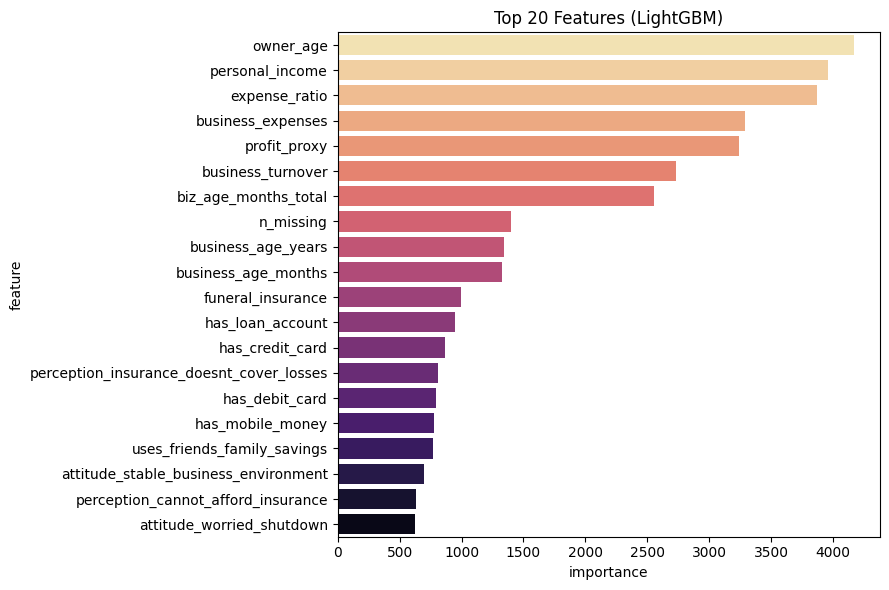

In [13]:
# feature importance (LightGBM sur tout le train)
m_fi = lgb.LGBMClassifier(objective='multiclass', num_class=N_CLASSES,
                           n_estimators=500, class_weight='balanced',
                           random_state=SEED, verbose=-1)
m_fi.fit(X, y)

fi = pd.DataFrame({'feature': FEATS, 'importance': m_fi.feature_importances_})\
       .sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(9, 6))
sns.barplot(data=fi, y='feature', x='importance', palette='magma_r')
plt.title('Top 20 Features (LightGBM)')
plt.tight_layout()
plt.show()

## 8. Soumission

In [14]:
submission = pd.DataFrame({
    'ID'    : test_df[ID_COL].values,
    'Target': le_tgt.inverse_transform(y_test_pred)
})

submission.to_csv('submission.csv', index=False)

print(submission['Target'].value_counts())
print('\n submission.csv !')

Target
Low       1583
Medium     716
High       106
Name: count, dtype: int64

 submission.csv !
